In [1]:
from eval import comparision_histplot, calculate_mean_cov, comparision_histplot_simulation

In [2]:
import numpy as np

In [3]:
training_data_path = "/home/yinbinha/adapted_diffusion_model/empirical_analysis_data/training_data_example.npy"

In [4]:
training_data = np.load(training_data_path)

In [5]:
training_data = training_data[:, :4]

In [6]:
np.shape(training_data)

(1194, 4)

In [7]:
import glob
import os

In [8]:
# Folder path
folder = "/home/yinbinha/adapted_diffusion_model/samples/dfm_training_data_example_ts1763542066_seed42"

# Get all batch files sorted by batch number
files = sorted(glob.glob(os.path.join(folder, "sample_batch*.npy")))

# Load and combine
arrays = []
for f in files:
    arr = np.load(f)
    if arr.shape[1] != 4:
        raise ValueError(f"File {f} has unexpected shape {arr.shape}")
    arrays.append(arr)
    
dit = np.concatenate(arrays, axis=0)

In [9]:
dit.shape

(8192, 4)

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def comparision_histplot(stock_i, training_return_data, generated_return_data, 
                        bins_num=50, x_bound=0.1, y_bound=0.1, zoomin_bound=0.05, 
                        filter_range=(-0.2, 0.2), outlier_percentile=1.0):
    """
    Plot histogram with Density Curve (KDE). 
    Outliers are removed ONLY from generated data (training data is assumed clean).
    """
    
    # 1. Extract data
    gen_data = generated_return_data[:, stock_i]
    train_data = training_return_data[:, stock_i]

    # 2. Outlier Removal (Generated Data Only)
    if filter_range is not None:
        lower, upper = filter_range
        gen_data_clean = gen_data[(gen_data >= lower) & (gen_data <= upper)]
        print(f"--- Filtering Data [{lower}, {upper}] ---")
        print(f"Kept {len(gen_data_clean)} Generated samples and {len(train_data)} Training samples.")
    else:
        gen_data_clean = gen_data

    # 3. Print Statistics (Min/Max restored)
    # Note: Printing stats of the data actually being plotted (cleaned gen vs raw train)
    print("\nStatistics:")
    print("Generated Samples: Min {:.4f}, Max {:.4f}, Mean {:.4f}, Var {:.4f}".format(
        gen_data_clean.min(), gen_data_clean.max(), gen_data_clean.mean(), gen_data_clean.var()))
    
    print("Training Samples:  Min {:.4f}, Max {:.4f}, Mean {:.4f}, Var {:.4f}".format(
        train_data.min(), train_data.max(), train_data.mean().item(), train_data.var().item()))

    # 4. Create figure
    fig, axes = plt.subplots(1, 2, figsize=(8, 3), dpi=400)
    
    # --- Plot Generated Data ---
    sns.histplot(ax=axes[0], data=gen_data_clean, bins=bins_num, alpha=0.5,
                stat="proportion", color="C0", label="Generated",
                kde=True, line_kws={'linewidth': 2, 'linestyle': '-'})
    
    # Calculate bin edges from training data to ensure consistent alignment
    bin_edges = np.histogram(train_data, bins=bins_num, density=False)[1]
    
    # --- Plot Training Data ---
    sns.histplot(ax=axes[1], data=train_data, bins=bin_edges, alpha=0.5,
                stat="proportion", color="C2", label="Training",
                kde=True, line_kws={'linewidth': 2, 'linestyle': '-'})

    # 5. Configure axes
    for ax in axes:
        ax.set_xlim(-x_bound, x_bound)
        ax.tick_params(axis='x', labelsize=12)
        ax.set_ylim(0, y_bound)
        ax.set_yticks(np.linspace(0, y_bound, 4))
        ax.tick_params(axis='y', labelsize=12)
        ax.set_ylabel("Frequency", fontsize=12)
        ax.legend(fontsize=12, loc='upper right')
        
        # Border style
        for spine in ax.spines.values():
            spine.set_color("black")
            spine.set_linewidth(1)

    # 6. Zoom-in Effect
    if zoomin_bound > 0:
        def custom_formatter(x, pos):
            return f"{x:.2f}"

        for ax in axes:
            axins = ax.inset_axes([0.1, 0.4, 0.28, 0.5])
            
            is_gen = (ax == axes[0])
            # Select data: Cleaned Gen data vs Raw Train data
            data_zoom = gen_data_clean if is_gen else train_data
            bins_zoom = bins_num if is_gen else bin_edges
            color_zoom = "C0" if is_gen else "C2"

            sns.histplot(ax=axins, data=data_zoom, bins=bins_zoom, alpha=0.5,
                        color=color_zoom, stat="proportion",
                        kde=True, line_kws={'linewidth': 1.5})
            
            axins.set_xlim(-zoomin_bound, zoomin_bound)
            axins.set_ylim(0, y_bound) 
            axins.set_yticks([])
            axins.set_ylabel("")
            axins.yaxis.set_major_formatter(plt.FuncFormatter(custom_formatter))
            
            for spine in axins.spines.values():
                spine.set_linestyle((0, (5, 4, 1, 4)))
                spine.set_linewidth(1)

    plt.tight_layout()
    plt.show()
    
    return bin_edges

--- Filtering Data [-0.2, 0.2] ---
Kept 8071 Generated samples and 1194 Training samples.

Statistics:
Generated Samples: Min -0.1552, Max 0.1539, Mean -0.0006, Var 0.0007
Training Samples:  Min -0.0704, Max 0.0740, Mean -0.0010, Var 0.0008


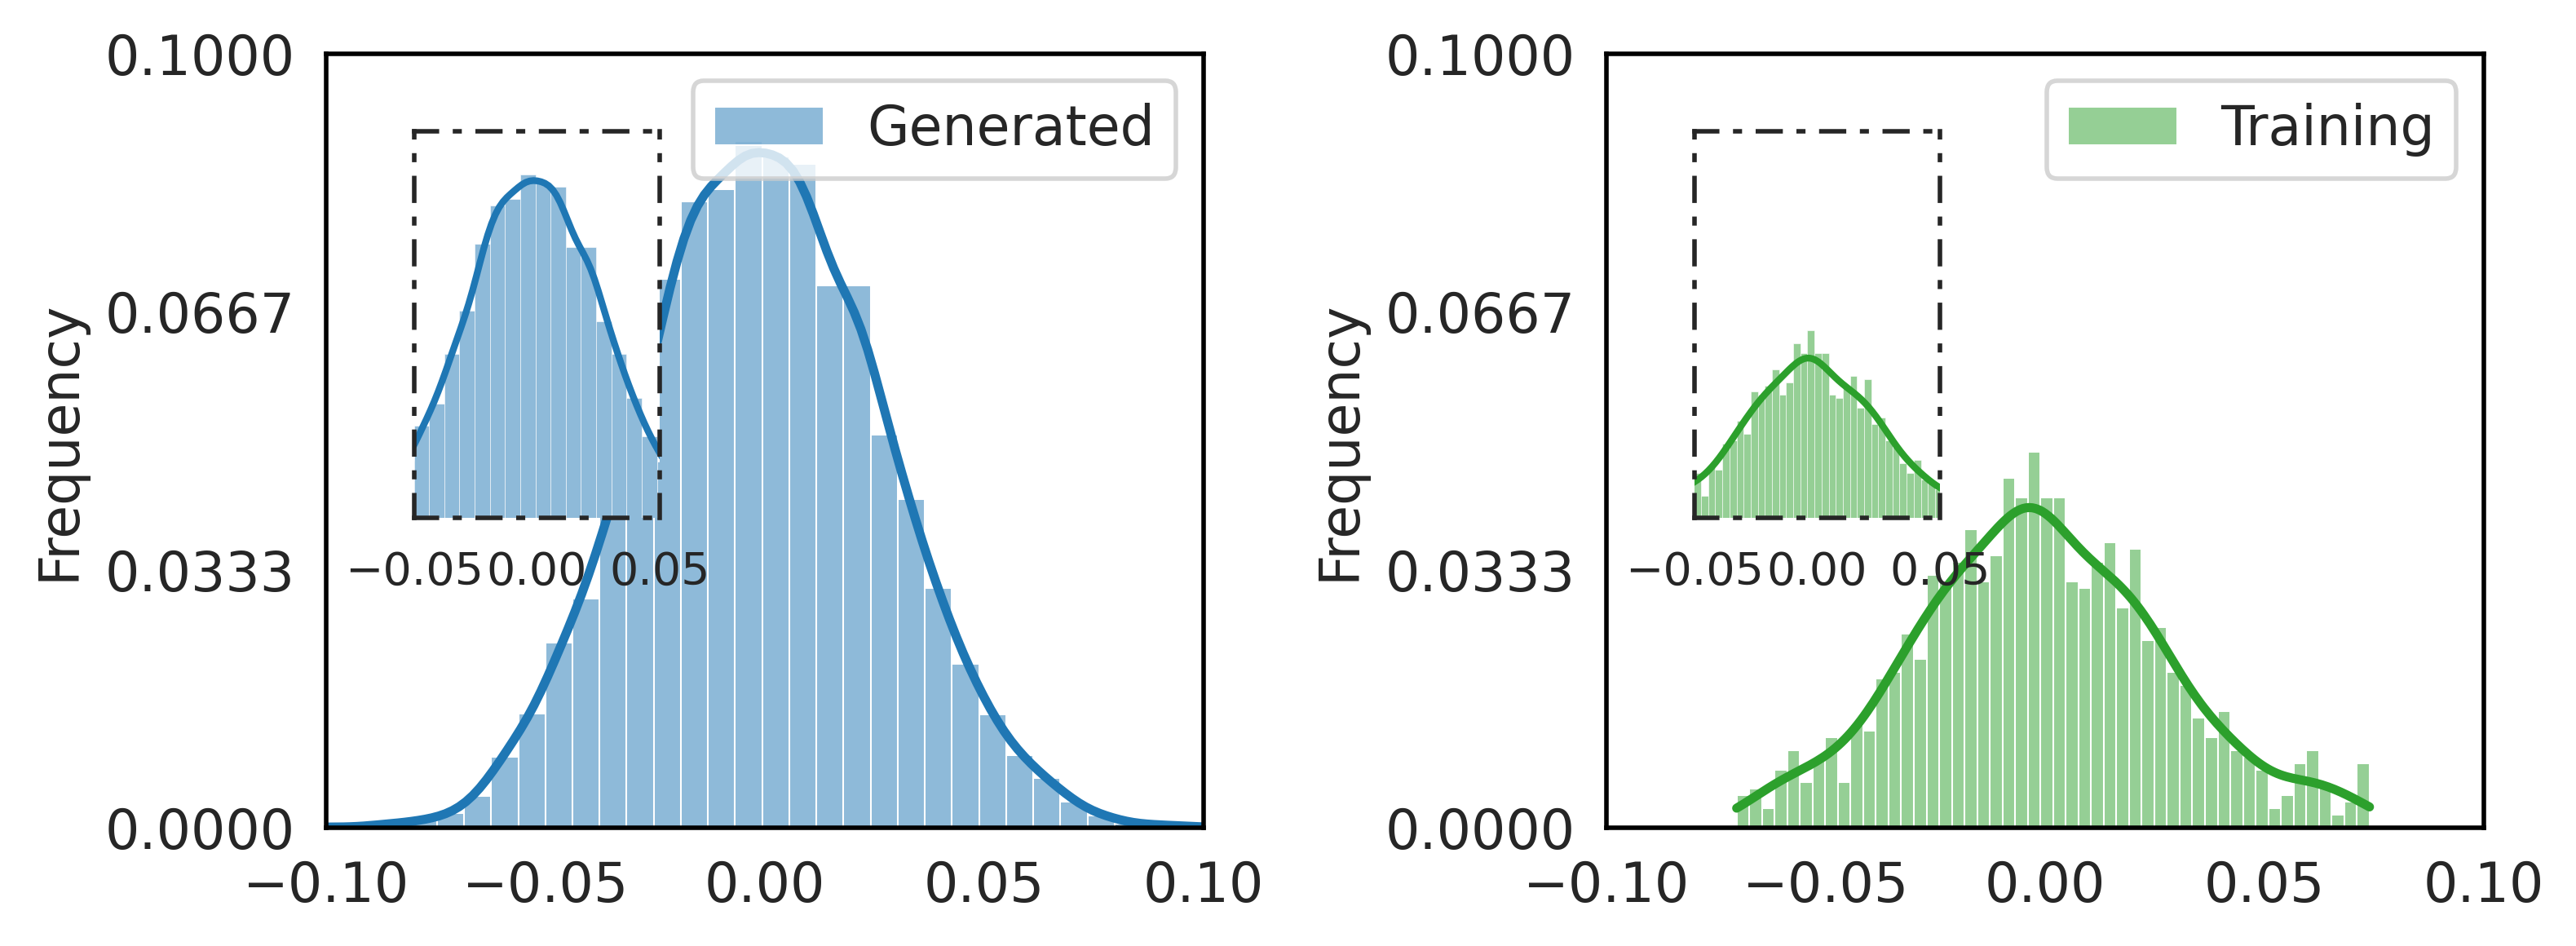

array([-0.070367  , -0.06748054, -0.06459408, -0.06170762, -0.05882116,
       -0.0559347 , -0.05304824, -0.05016178, -0.04727532, -0.04438886,
       -0.0415024 , -0.03861594, -0.03572948, -0.03284302, -0.02995656,
       -0.0270701 , -0.02418364, -0.02129718, -0.01841072, -0.01552426,
       -0.0126378 , -0.00975134, -0.00686488, -0.00397842, -0.00109196,
        0.0017945 ,  0.00468096,  0.00756742,  0.01045388,  0.01334034,
        0.0162268 ,  0.01911326,  0.02199972,  0.02488618,  0.02777264,
        0.0306591 ,  0.03354556,  0.03643202,  0.03931848,  0.04220494,
        0.0450914 ,  0.04797786,  0.05086432,  0.05375078,  0.05663724,
        0.0595237 ,  0.06241016,  0.06529662,  0.06818308,  0.07106954,
        0.073956  ])

In [15]:
comparision_histplot(
    stock_i=1, 
    training_return_data=training_data, 
    generated_return_data=dit, 
)

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def comparison_qqplot(stock_i, training_return_data, generated_return_data, filter_range=(-0.2, 0.2), zoomin_bound=0.1):
    """
    Plot Q-Q comparison with a Zoom-in inset around the origin (0,0).
    
    Args:
        zoomin_bound (float): The +/- limit for the zoomed-in view (e.g., 0.05 for +/-5% returns).
    """
    
    # 1. Extract data
    gen_data = generated_return_data[:, stock_i]
    train_data = training_return_data[:, stock_i]

    # 1.1. Apply Hard Filter (Keep only data between -0.2 and 0.2)
    if filter_range is not None:
        min_cut, max_cut = filter_range
        
        # Filter Generated
        gen_mask = (gen_data >= min_cut) & (gen_data <= max_cut)
        gen_data = gen_data[gen_mask]
        
        # Filter Training
        train_mask = (train_data >= min_cut) & (train_data <= max_cut)
        train_data = train_data[train_mask]
        
        print(f"--- Filtering Data [{min_cut}, {max_cut}] ---")
        print(f"Kept {len(gen_data)} Generated samples and {len(train_data)} Training samples.")

    # 2. Print Statistics
    print("\nStatistics:")
    print("Generated: Min {:.4f}, Max {:.4f}, Mean {:.4f}, Var {:.4f}".format(
        gen_data.min(), gen_data.max(), gen_data.mean(), gen_data.var()))
    
    print("Training:  Min {:.4f}, Max {:.4f}, Mean {:.4f}, Var {:.4f}".format(
        train_data.min(), train_data.max(), train_data.mean().item(), train_data.var().item()))

    # 3. Calculate Quantiles
    quantiles = np.linspace(0, 100, 1000)
    q_train = np.percentile(train_data, quantiles)
    q_gen = np.percentile(gen_data, quantiles)

    # Determine common limits for the main square plot
    min_val = min(q_train.min(), q_gen.min())
    max_val = max(q_train.max(), q_gen.max())
    buffer = (max_val - min_val) * 0.05
    lims = [min_val - buffer, max_val + buffer]

    # 4. Create Figure
    fig, ax = plt.subplots(figsize=(6, 6), dpi=400)
    
    # --- Main Plot ---
    ax.scatter(q_train, q_gen, alpha=0.6, s=15, color="C0", label="Quantiles", edgecolor='none')
    ax.plot(lims, lims, 'k--', alpha=0.7, label="Perfect Match") # 45-degree line

    # Main Axes Configuration
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xlabel("Training Data Quantiles", fontsize=12)
    ax.set_ylabel("Generated Data Quantiles", fontsize=12)
    ax.set_title(f"Q-Q Plot: Stock {stock_i}", fontsize=14)
    ax.legend(loc='upper left', fontsize=12)
    ax.grid(True, linestyle=':', alpha=0.6)

    for spine in ax.spines.values():
        spine.set_color("black")
        spine.set_linewidth(1)

    # # --- Zoom-in Inset ---
    # # Place inset in bottom-right corner (usually empty in Q-Q plots)
    # axins = ax.inset_axes([0.55, 0.05, 0.4, 0.4]) 
    
    # # Plot data on inset
    # axins.scatter(q_train, q_gen, alpha=0.8, s=20, color="C0", edgecolor='none')
    # axins.plot(lims, lims, 'k--', alpha=0.7) # 45-degree line
    
    # # Set Zoom Limits (around 0)
    # axins.set_xlim(-zoomin_bound, zoomin_bound)
    # axins.set_ylim(-zoomin_bound, zoomin_bound)
    
    # # Style the Inset
    # axins.grid(True, linestyle=':', alpha=0.5)
    # axins.set_title(f"Zoom (±{zoomin_bound})", fontsize=10)
    
    # # Add connector lines pointing to the zoom area
    # indicating that we are zooming in on the center
    # ax.indicate_inset_zoom(axins, edgecolor="black", alpha=0.4)
    
    # # Custom border for inset to make it pop
    # for spine in axins.spines.values():
    #     spine.set_linestyle('--')
    #     spine.set_color('gray')

    plt.tight_layout()
    plt.show()

--- Filtering Data [-0.2, 0.2] ---
Kept 7976 Generated samples and 1194 Training samples.

Statistics:
Generated: Min -0.1935, Max 0.1917, Mean -0.0006, Var 0.0007
Training:  Min -0.0659, Max 0.0708, Mean -0.0010, Var 0.0007


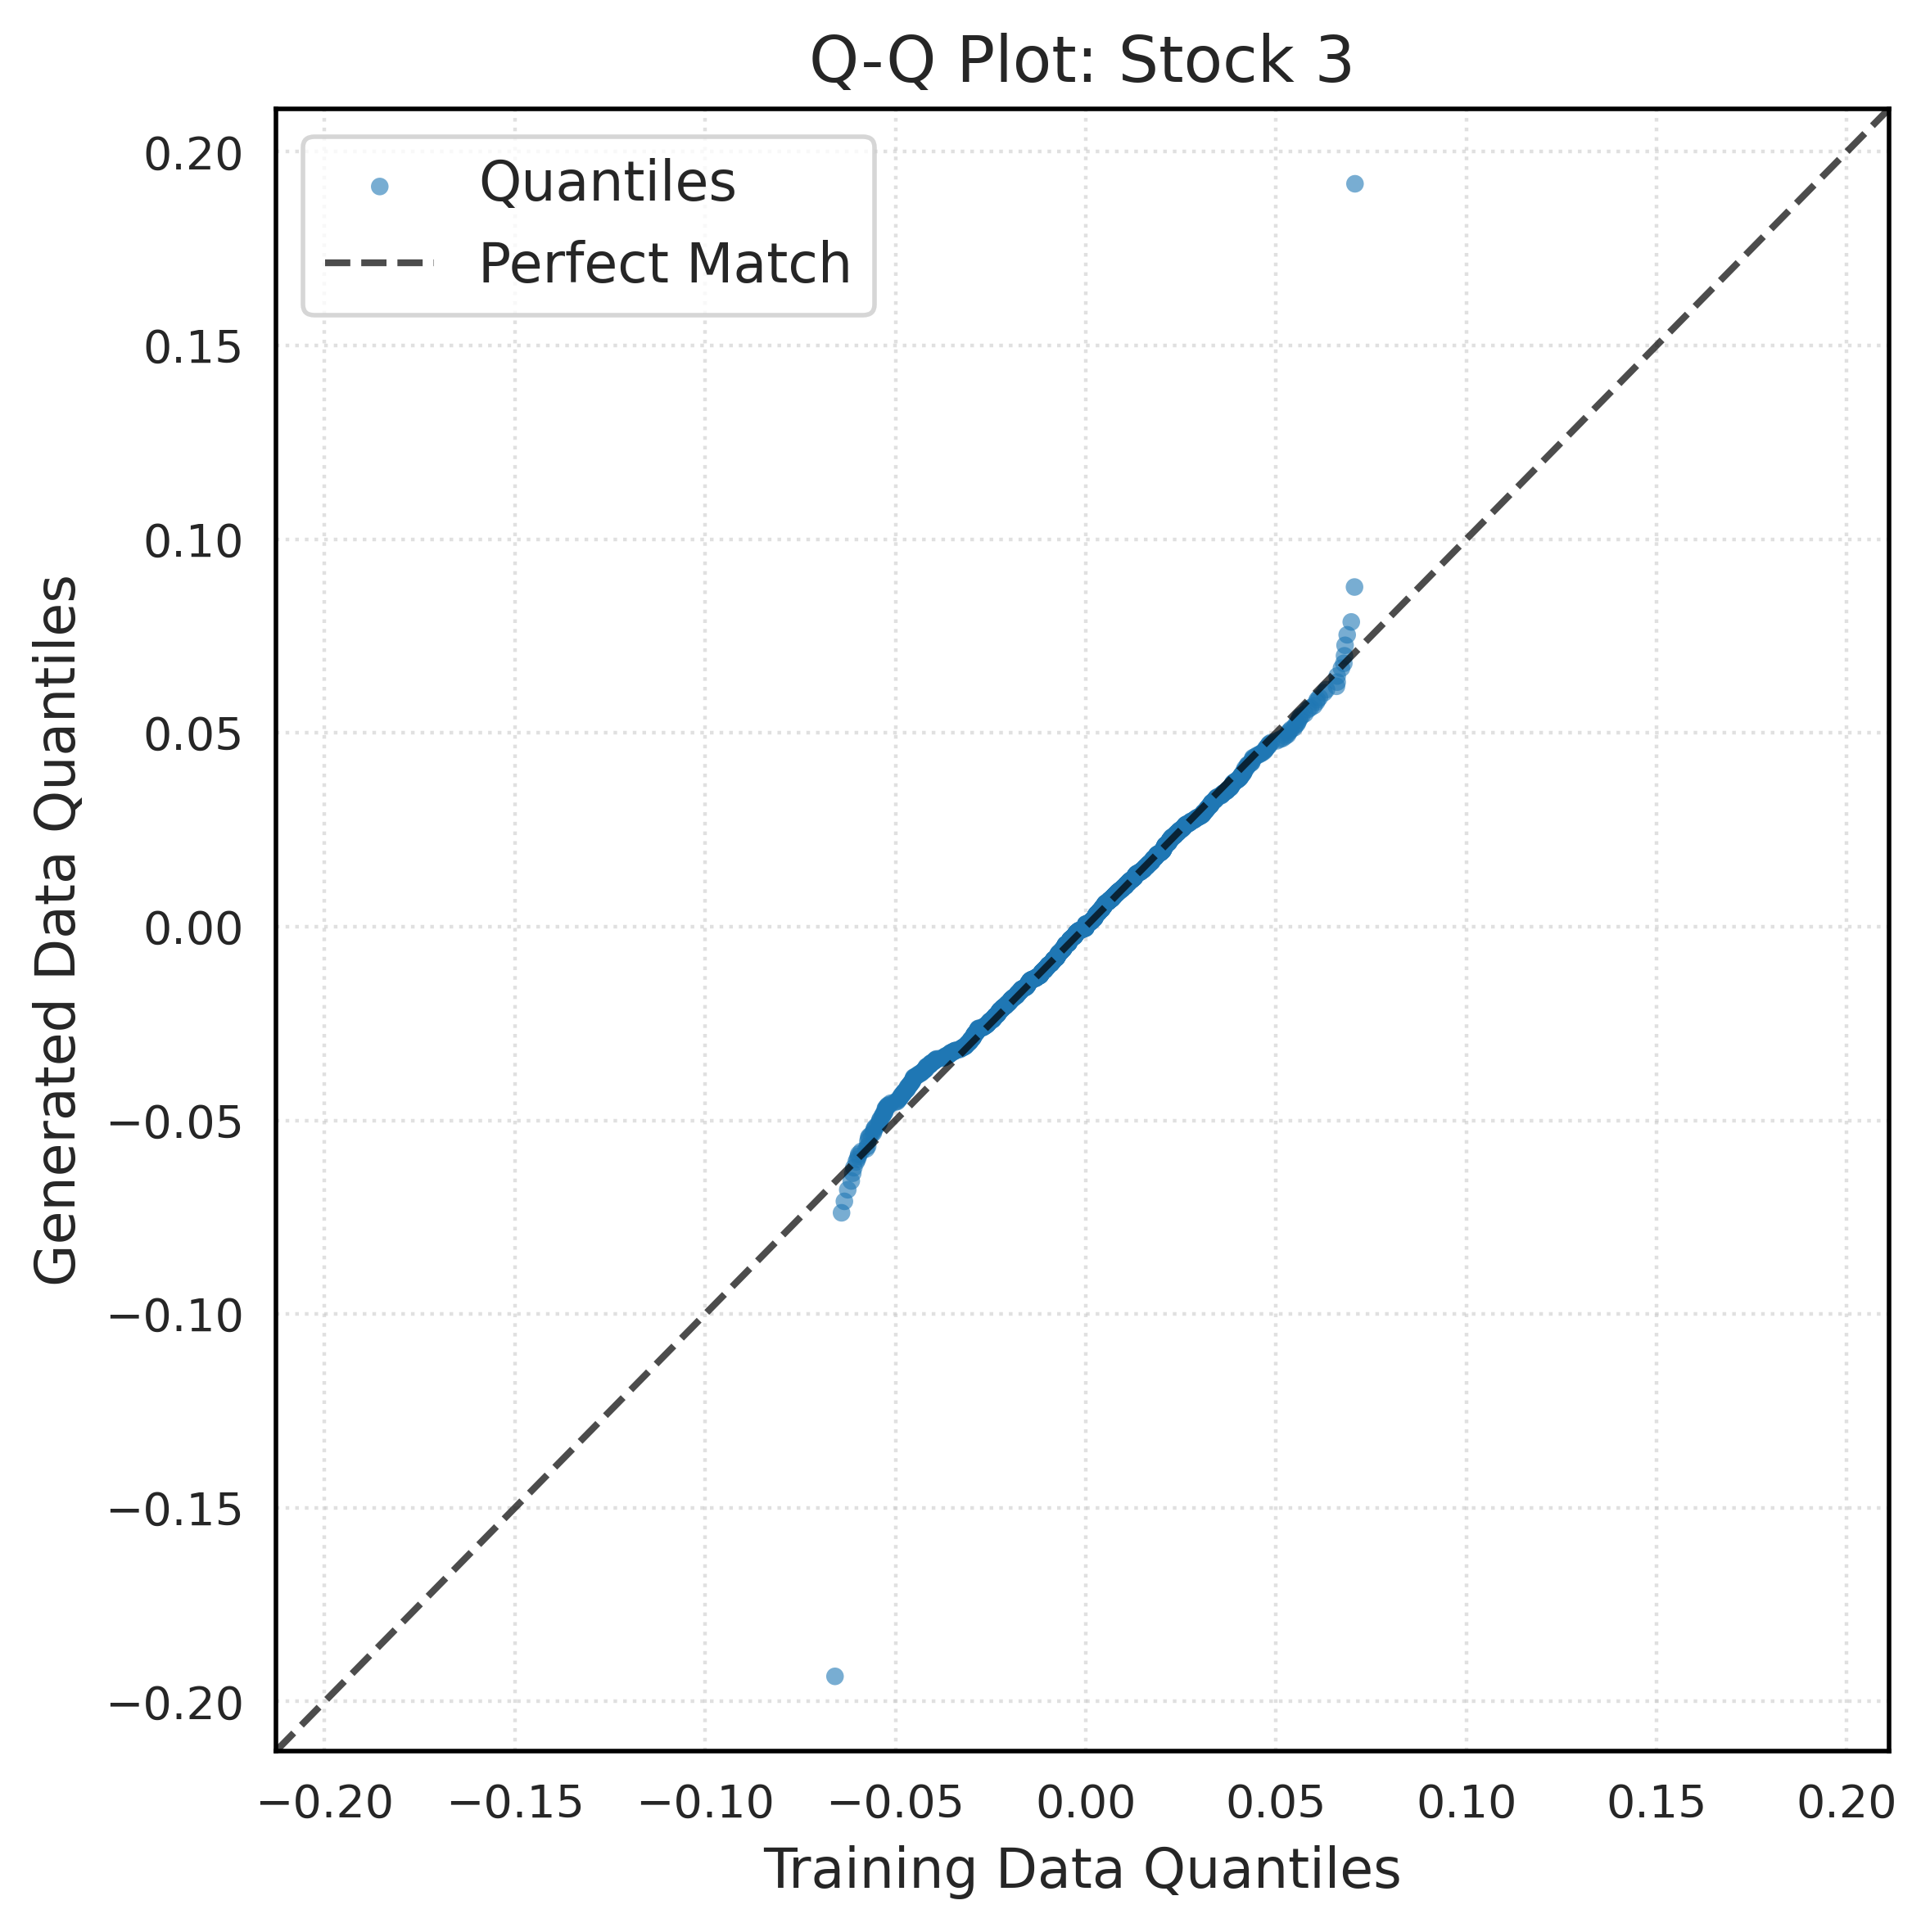

In [39]:
comparison_qqplot(3, training_return_data=training_data, generated_return_data=dit)